# Pricing and Hedging of European Options

Binomial-tree (Cox-Ross-Rubinstein), Monte-Carlo and closed-form Black-Scholes pricing of European options, plus the dynamic replicating strategy.

## Contents
1. [Risk-neutral probability](#1-risk-neutral-probability)
2. [Closed-form price](#2-closed-form-price)
3. [Direct pricer](#3-direct-pricer)
4. [Backward-induction pricer](#4-backward-induction-pricer)
5. [Dynamic hedging](#5-dynamic-hedging)
6. [Black-Scholes model](#6-black-scholes-model)
7. [Monte-Carlo pricer](#7-monte-carlo-pricer)
8. [Closed-form Black-Scholes put](#8-closed-form-black-scholes-put)
9. [Monte-Carlo vs closed form](#9-monte-carlo-vs-closed-form)
10. [CRR convergence to Black-Scholes](#10-crr-convergence-to-black-scholes)


In [45]:
import numpy as np
import math
import matplotlib.pyplot as plt


## 1. Risk-neutral probability

Discrete grid $t_0=0<\dots<t_N=T$, $\delta=T/N$. Riskless asset $(1+r_N)^i$ at $t_i$; risky asset $S^{(N)}_{t_i}=T^{(N)}_i S^{(N)}_{t_{i-1}}$ with $T^{(N)}_i\in\{1+h_N,\,1+b_N\}$ i.i.d. and $b_N<r_N<h_N$.

$Q$ makes the discounted price a martingale, i.e. $E_Q[T_1^{(N)}]=1+r_N$:

$$q_N = \frac{r_N - b_N}{h_N - b_N}$$


## 2. Closed-form price

$$Prix^{(N)} = \frac{1}{(1+r_N)^N}\sum_{k=0}^{N} \binom{N}{k} q_N^k (1-q_N)^{N-k}\, f\!\left(s(1+h_N)^k(1+b_N)^{N-k}\right)$$

where $k$ is the number of up-moves among the $N$ steps.


## 3. Direct pricer

In [46]:
def price1(N, rN, hN, bN, s, f):
    """Binomial price via direct summation over the number of up-moves.

    Parameters
    ----------
    N : int      number of time steps
    rN : float   risk-free rate per step
    hN : float   up factor per step
    bN : float   down factor per step
    s : float    initial spot price
    f : callable payoff function

    Returns
    -------
    float : option price
    """
    qN = (rN - bN) / (hN - bN)
    total = 0.0
    for k in range(N + 1):
        ST = s * (1 + hN)**k * (1 + bN)**(N - k)
        proba = math.comb(N, k) * qN**k * (1 - qN)**(N - k)
        total += proba * f(ST)
    return total / (1 + rN)**N


In [47]:
call = lambda x: max(x - 100, 0)
price1(20, 0.01, 0.05, -0.05, 100, call)


20.078658207286075

## 4. Backward-induction pricer

$$v_N(S_{t_N}) = f(S_{t_N}), \qquad v_k(S_{t_k}) = \frac{1}{1+r_N}\Big(q_N\, v_{k+1}(\text{up}) + (1-q_N)\, v_{k+1}(\text{down})\Big)$$


In [48]:
def price2(N, rN, hN, bN, s, f):
    """Binomial price via backward induction on the recombining tree."""
    qN = (rN - bN) / (hN - bN)
    prices = np.zeros(N + 1)
    for k in range(N + 1):
        prices[k] = s * (1 + hN)**k * (1 + bN)**(N - k)
    V = [f(x) for x in prices]
    for k in range(N - 1, -1, -1):
        for i in range(k + 1):
            V[i] = (1 / (1 + rN)) * (qN * V[i + 1] + (1 - qN) * V[i])
    return V


In [49]:
call = lambda x: max(x - 100, 0)
price2(3, 0.01, 0.05, -0.05, 100, call)[0]


np.float64(5.290978073397971)

## 5. Dynamic hedging

At date $t_{k-1}$ with asset price $x$, the replicating portfolio holds $\alpha_{k-1}$ risky assets and $\beta_{k-1}$ riskless assets. Matching $v_k$ in both states gives

$$\alpha_{k-1}(x) = \frac{v_k\big((1+h_N)x\big) - v_k\big((1+b_N)x\big)}{x(h_N - b_N)} \qquad \text{(Delta)}$$

$$\beta_{k-1}(x) = \frac{(1+h_N)\,v_k\big((1+b_N)x\big) - (1+b_N)\,v_k\big((1+h_N)x\big)}{(1+r_N)^k(h_N - b_N)}$$

At node $(k-1,j)$, $x = s(1+h_N)^j(1+b_N)^{k-1-j}$; up child is `V[j+1]`, down child `V[j]`.


In [50]:
def hedge(N, rN, hN, bN, s, f):
    """Replicating strategy (alpha, beta) at every node before maturity.

    Returns
    -------
    alpha, beta : lists of lists, indexed by step then node.
    """
    alpha = []
    beta = []
    for k in range(1, N + 1):
        alpha_k = []
        beta_k = []
        for j in range(k):
            x = s * (1 + hN)**j * (1 + bN)**(k - 1 - j)
            v_up = price2(N - k, rN, hN, bN, (1 + hN) * x, f)[0]
            v_down = price2(N - k, rN, hN, bN, (1 + bN) * x, f)[0]
            a = (v_up - v_down) / (x * (hN - bN))
            b = ((1 + hN) * v_down - (1 + bN) * v_up) / ((1 + rN)**k * (hN - bN))
            alpha_k.append(a)
            beta_k.append(b)
        alpha.append(alpha_k)
        beta.append(beta_k)
    return alpha, beta


In [51]:
call = lambda x: max(x - 100, 0)
hedge(2, 0.01, 0.05, -0.05, 100, call)


([[np.float64(0.6089108910891088)], [0.0, np.float64(0.9761904761904762)]],
 [[np.float64(-57.27379668659934)], [0.0, np.float64(-95.45632781099891)]])

## 6. Black-Scholes model

Riskless asset $\exp(rt)$; risky asset solving $dS_t = S_t(r\,dt + \sigma\,dB_t)$, $S_0 = s$, with $B$ a standard Brownian motion.

Applying Itô's formula to $\ln(S_t)$ gives

$$S_t = s\exp\!\left[\left(r - \frac{\sigma^2}{2}\right)t + \sigma B_t\right]$$


## 7. Monte-Carlo pricer

$$P := \mathbb{E}\big[e^{-rT}f(S_T)\big], \qquad \widehat{P}^{(n)} := \frac{1}{n}\sum_{i=1}^n e^{-rT} f\!\left(s\exp\!\left[\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\,\xi_i\right]\right)$$

with $(\xi_i)_i$ i.i.d. $\mathcal{N}(0,1)$. The summands are i.i.d. with mean $P$, so by the strong law of large numbers $\widehat{P}^{(n)} \to P$ almost surely.


In [52]:
import random
import math

def price3(n,s,r,sigma,T,f) :
    sum = 0
    for i in range(n) : 
        eps_i = random.gauss(0,1)
        S_i = s *math.exp((r-sigma**2 /2)*T + sigma*math.sqrt(T)*eps_i) 
        payoff_i = f(S_i)
        payoff_actualise = math.exp(-r*T) * payoff_i
        sum += payoff_actualise
    return 1/n * sum
        
        
        
        

Monte-Carlo price as a function of the number of simulations.

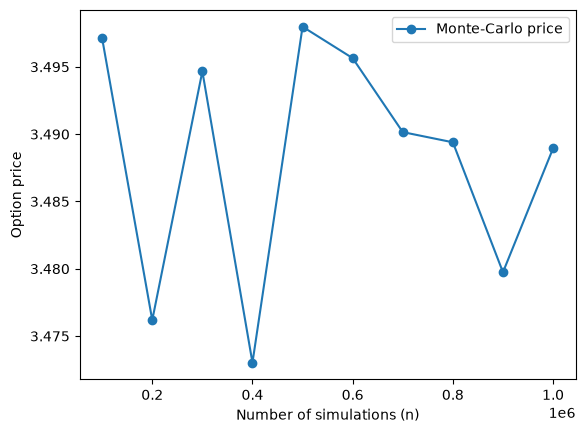

In [53]:
import matplotlib.pyplot as plt

r = 0.01
sigma = 0.1
s = 100
T = 1
f = lambda x: max(100 - x, 0)

n_values = [10**5 * k for k in range(1, 11)]
mc_prices = [price3(n, s, r, sigma, T, f) for n in n_values]

plt.plot(n_values, mc_prices, marker='o', label='Monte-Carlo price')
plt.xlabel("Number of simulations (n)")
plt.ylabel("Option price")
plt.legend()
plt.show()


## 8. Closed-form Black-Scholes put

$$Prix_{BS} = -sF(-d) + Ke^{-rT}F(-d+\sigma\sqrt{T}), \qquad d = \frac{1}{\sigma\sqrt{T}}\left[\ln\!\left(\frac{s}{K}\right) + \left(r+\frac{\sigma^2}{2}\right)T\right]$$

with $F$ the standard normal CDF.


In [54]:
from scipy.stats import norm

def put(s,r,sigma,T,K):
    d = (math.log(s/K)+(r+ sigma**2 / 2)*T) /(sigma*math.sqrt(T))
    price = -s * norm.cdf(-d) + K*math.exp(-r*T)*norm.cdf(-d+sigma*math.sqrt(T))
    return price

In [55]:
put(100,0.01,0.1,1,90)

np.float64(0.5815000751362422)

## 9. Monte-Carlo vs closed form

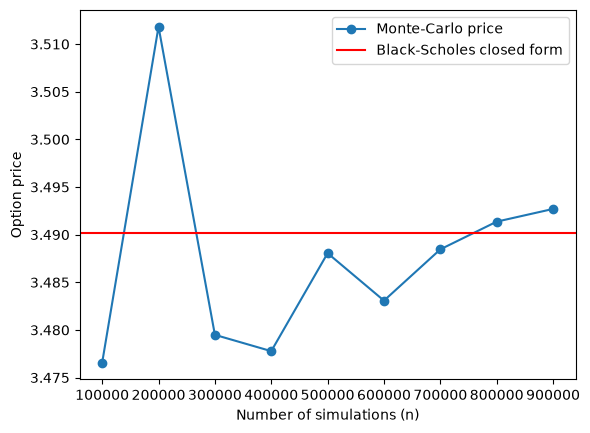

In [56]:
import matplotlib.pyplot as plt

r = 0.01
sigma = 0.1
s = 100
T = 1
f = lambda x: max(100 - x, 0)

n_values = [10**5 * k for k in range(1, 10)]
mc_prices = [price3(n, s, r, sigma, T, f) for n in n_values]
bs_price = put(s, r, sigma, T, K=100)

plt.plot(n_values, mc_prices, marker='o', label='Monte-Carlo price')
plt.axhline(y=bs_price, color='red', label="Black-Scholes closed form")
plt.xlabel("Number of simulations (n)")
plt.ylabel("Option price")
plt.legend()
plt.show()


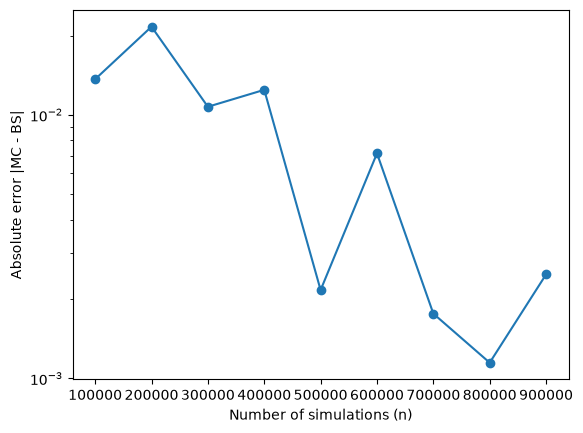

In [57]:
errors = [abs(p - bs_price) for p in mc_prices]
plt.plot(n_values, errors, marker='o')
plt.xlabel("Number of simulations (n)")
plt.ylabel("Absolute error |MC - BS|")
plt.yscale('log')
plt.show()


**Observation.** The Monte-Carlo estimate oscillates around the closed-form price without converging monotonically: each $\widehat{P}^{(n)}$ is itself a random variable, so a larger $n$ can land further from $P$ than a smaller one. The strong law guarantees convergence as $n \to \infty$, and the central limit theorem puts the typical error at order $1/\sqrt{n}$ — visible here as an error staying in the $10^{-3}$ to $10^{-2}$ range across the whole grid. A monotone decay would only appear by averaging several independent runs per $n$.


## 10. CRR convergence to Black-Scholes

With $r_N = rT/N$, $h_N = (1+r_N)e^{\sigma\sqrt{T/N}} - 1$, $b_N = (1+r_N)e^{-\sigma\sqrt{T/N}} - 1$.


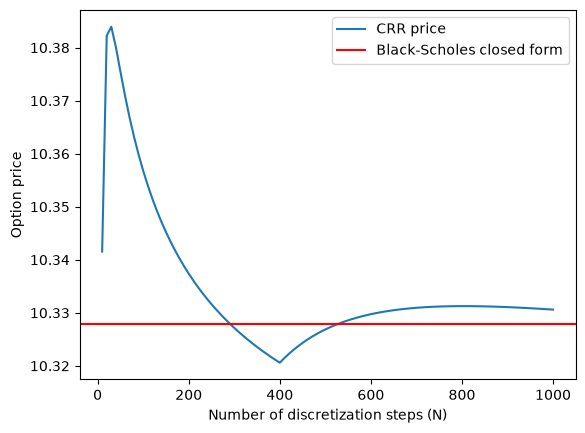

In [58]:
import matplotlib.pyplot as plt
import math

r = 0.03
sigma = 0.3
s = 100
T = 1
f = lambda x: max(100 - x, 0)

N_values = [10 * k for k in range(1, 101)]
crr_prices = []
for N in N_values:
    rN = r * T / N
    hN = (1 + rN) * math.exp(sigma * math.sqrt(T / N)) - 1
    bN = (1 + rN) * math.exp(-sigma * math.sqrt(T / N)) - 1
    crr_prices.append(price2(N, rN, hN, bN, s, f)[0])

bs_price = put(s, r, sigma, T, K=100)

plt.plot(N_values, crr_prices, label='CRR price')
plt.axhline(y=bs_price, color='red', label="Black-Scholes closed form")
plt.xlabel("Number of discretization steps (N)")
plt.ylabel("Option price")
plt.legend()
plt.show()


**Observation.** The CRR price converges to the Black-Scholes price as $N$ grows, confirming that the discrete model approximates the continuous one. Unlike the Monte-Carlo estimator, the convergence is deterministic: the gap comes purely from time discretization, not sampling noise. The curve overshoots for small $N$ and settles into damped oscillations that narrow steadily as $N$ increases.
